# 🚀 GLiNER Fine-tune Pipeline — Kaggle GPU

## Chuẩn bị trước khi chạy

**1. Upload dataset lên Kaggle:**
- Tạo Kaggle Dataset mới → upload file `train_dataset.json`
  (file này được tạo bởi `build_dataset_v2.py` chạy ở local)
- Vào notebook → `+ Add Data` → chọn dataset vừa tạo

**2. Bật GPU:**
- `Session Options` → `Accelerator` → **GPU P100** (hoặc T4)

---

## Luồng thực hiện
1. Cài thư viện
2. Load `train_dataset.json` từ Kaggle Dataset
3. Split **80% Train | 10% Val | 10% Test** (stratified)
4. Chunking (max_len=384, overlap=64)
5. Đánh giá **baseline** GLiNER gốc → F1 + nDCG@10
6. Fine-tune GLiNER
7. Đánh giá **sau fine-tune** → F1 + nDCG@10
8. So sánh & vẽ biểu đồ
9. Lưu model & artifacts

In [1]:
# ── 1. Cài thư viện ───────────────────────────────────────────────────────────
!pip install -q gliner
print("✅ Thư viện đã cài xong")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.4/170.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 77.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.

In [2]:
# ── 2. Cấu hình đường dẫn ─────────────────────────────────────────────────────
import os, json, gc, random, math, shutil
from collections import Counter
from pathlib import Path
import torch

# ── Tìm train_dataset.json trong Kaggle Dataset đã mount ─────────────────────
TRAIN_DATASET_FILE = ""
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f == "train_dataset.json":
            TRAIN_DATASET_FILE = os.path.join(root, f)
            break
    if TRAIN_DATASET_FILE:
        break

if not TRAIN_DATASET_FILE:
    raise FileNotFoundError(
        "❌ Không tìm thấy train_dataset.json.\n"
        "   → Vào '+ Add Data', chọn Kaggle Dataset chứa train_dataset.json."
    )

OUTPUT_DIR        = "/kaggle/working/gliner_finetuned"
BASELINE_MODEL_ID = "urchade/gliner_multi-v2.1"

os.makedirs(OUTPUT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"📁 train_dataset   : {TRAIN_DATASET_FILE}")
print(f"📁 output_dir      : {OUTPUT_DIR}")
print(f"🖥️  Device          : {device}")
if device == "cuda":
    print(f"🎮 GPU             : {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

📁 train_dataset   : /kaggle/input/datasets/hongqunon/train-dataset/train_dataset.json
📁 output_dir      : /kaggle/working/gliner_finetuned
🖥️  Device          : cuda
🎮 GPU             : Tesla T4
💾 VRAM            : 15.6 GB


In [3]:
# ── 3. Load dataset & Stratified Split 80 | 10 | 10 ──────────────────────────
print("📂 Đọc train_dataset.json...")
with open(TRAIN_DATASET_FILE, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# Thống kê dataset
label_counter = Counter()
for item in raw_data:
    for ent in item["ner"]:
        label_counter[ent[2]] += 1
lengths = [len(item["tokenized_text"]) for item in raw_data]

print(f"\n{'='*50}")
print("DATASET STATISTICS")
print(f"{'='*50}")
print(f"  Total samples : {len(raw_data):,}")
print(f"  Label counts  : {dict(label_counter)}")
print(f"  Token length  : min={min(lengths)}, max={max(lengths)}, avg={sum(lengths)/len(lengths):.0f}")
print(f"  Samples > 384 : {sum(1 for l in lengths if l > 384):,}")

# ── Tỉ lệ chia ───────────────────────────────────────────────────────────────
TRAIN_RATIO = 0.8   # 80%
VAL_RATIO   = 0.1   # 10%
TEST_RATIO  = 0.1   # 10%
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9


def stratified_split(data, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, seed=42):
    """
    Chia dữ liệu theo nhãn dominant và độ khó (số lượng entity) 
    để đảm bảo phân phối đều 'cái khó', 'cái bình thường' ở 3 tập.
    """
    random.seed(seed)
    groups = {}
    for item in data:
        labels   = [e[2] for e in item["ner"]]
        dominant = Counter(labels).most_common(1)[0][0] if labels else "NONE"
        
        # Phân loại độ khó
        n_ents = len(labels)
        if n_ents == 0: diff = "empty"
        elif n_ents <= 3: diff = "easy"
        elif n_ents <= 8: diff = "normal"
        else: diff = "hard"
        
        key = f"{dominant}_{diff}"
        groups.setdefault(key, []).append(item)

    train, val, test = [], [], []
    for key, items in groups.items():
        random.shuffle(items)
        n      = len(items)
        t_end  = int(n * train_ratio)
        v_end  = int(n * (train_ratio + val_ratio))
        train += items[:t_end]
        val   += items[t_end:v_end]
        test  += items[v_end:]
    random.shuffle(train)
    random.shuffle(val)
    random.shuffle(test)
    return train, val, test


def count_labels(data):
    c = Counter()
    for item in data:
        for e in item["ner"]: c[e[2]] += 1
    return dict(c)


raw_train, raw_val, raw_test = stratified_split(raw_data)
total = len(raw_data)

print(f"\n{'='*55}")
print(f"  SPLIT: {TRAIN_RATIO*100:.0f}% Train | {VAL_RATIO*100:.0f}% Val | {TEST_RATIO*100:.0f}% Test")
print(f"{'='*55}")
print(f"  Train : {len(raw_train):>6,}  ({len(raw_train)/total*100:.1f}%)  {count_labels(raw_train)}")
print(f"  Val   : {len(raw_val):>6,}  ({len(raw_val)/total*100:.1f}%)  {count_labels(raw_val)}")
print(f"  Test  : {len(raw_test):>6,}  ({len(raw_test)/total*100:.1f}%)  {count_labels(raw_test)}")
print(f"  Total : {total:>6,}")

📂 Đọc train_dataset.json...

DATASET STATISTICS
  Total samples : 7,992
  Label counts  : {'SKILL': 177411, 'MAJOR': 19200, 'EXPERIENCE': 10764}
  Token length  : min=7, max=2760, avg=418
  Samples > 384 : 3,638

  SPLIT: 80% Train | 10% Val | 10% Test
  Train :  6,389  (79.9%)  {'SKILL': 142571, 'MAJOR': 15371, 'EXPERIENCE': 8611}
  Val   :    800  (10.0%)  {'SKILL': 17537, 'EXPERIENCE': 1041, 'MAJOR': 1864}
  Test  :    803  (10.0%)  {'EXPERIENCE': 1112, 'SKILL': 17303, 'MAJOR': 1965}
  Total :  7,992


In [4]:
# ── 4. Chunking ───────────────────────────────────────────────────────────────
MAX_LEN = 384   # Kaggle P100/T4 chịu được với fp16
OVERLAP  = 64   # tránh mất entity bị cắt ngang


def chunk_data(data, max_len=MAX_LEN, overlap=OVERLAP):
    chunked = []
    for item in data:
        tokens, entities = item["tokenized_text"], item["ner"]
        if len(tokens) <= max_len:
            chunked.append(item)
            continue
        start = 0
        while start < len(tokens):
            end = min(start + max_len, len(tokens))
            chunk_ents = [
                [e[0] - start, e[1] - start, e[2]]
                for e in entities
                if e[0] >= start and e[1] < end
            ]
            if chunk_ents:
                chunked.append({"tokenized_text": tokens[start:end], "ner": chunk_ents})
            if end == len(tokens): break
            start += (max_len - overlap)
    return chunked


print("⏳ Đang chunking...")
train_data = chunk_data(raw_train)
val_data   = chunk_data(raw_val)
test_data  = chunk_data(raw_test)

print(f"\nAFTER CHUNKING (max_len={MAX_LEN}, overlap={OVERLAP})")
print(f"  Train chunks : {len(train_data):,}")
print(f"  Val chunks   : {len(val_data):,}")
print(f"  Test chunks  : {len(test_data):,}")

⏳ Đang chunking...

AFTER CHUNKING (max_len=384, overlap=64)
  Train chunks : 9,896
  Val chunks   : 1,220
  Test chunks  : 1,268


In [5]:
# ── 5. Đánh giá BASELINE (trước fine-tune) ───────────────────────────────────
from gliner import GLiNER

EVAL_LABELS  = ["SKILL", "MAJOR", "EXPERIENCE"]
THRESHOLD    = 0.3
NDCG_K       = 10
EVAL_SAMPLES = min(500, len(test_data))


def dcg(relevances, k):
    return sum((2**r - 1) / math.log2(i + 2) for i, r in enumerate(relevances[:k]))


def ndcg_for_sample(gold_set: set, preds: list, k: int) -> float:
    rel       = [1 if (p["start"], p["end"], p["label"]) in gold_set else 0 for p in preds]
    ideal_rel = sorted(rel, reverse=True)
    ideal     = dcg(ideal_rel, k)
    if ideal == 0:
        return 1.0 if all(r == 0 for r in rel[:k]) else 0.0
    return dcg(rel, k) / ideal


def compute_metrics(model, data, labels, threshold, ndcg_k, n_samples):
    """Tính F1 (exact span) và nDCG@k. Trả về dict per-label + overall."""
    random.seed(0)
    subset = random.sample(data, min(n_samples, len(data)))

    tp_all = fp_all = fn_all = 0
    ndcg_scores = []
    per_label = {l: {"tp": 0, "fp": 0, "fn": 0} for l in labels}

    model.eval()
    with torch.no_grad():
        for item in subset:
            tokens    = item["tokenized_text"]
            text      = " ".join(tokens)
            word_list = text.split()
            gold      = {(e[0], e[1], e[2]) for e in item["ner"]}

            preds_raw = model.predict_entities(text, labels, threshold=threshold, flat_ner=True)

            # Map character span → word-level token index
            preds = []
            for p in preds_raw:
                p_words = p["text"].split()
                n = len(p_words)
                for i in range(len(word_list) - n + 1):
                    if word_list[i:i+n] == p_words:
                        preds.append({"start": i, "end": i + n - 1,
                                      "label": p["label"], "score": p.get("score", 1.0)})
                        break

            # nDCG
            preds_sorted = sorted(preds, key=lambda x: x["score"], reverse=True)
            ndcg_scores.append(ndcg_for_sample(gold, preds_sorted, ndcg_k))

            # F1 exact span
            pred_set = {(p["start"], p["end"], p["label"]) for p in preds}
            tp_all += len(pred_set & gold)
            fp_all += len(pred_set - gold)
            fn_all += len(gold - pred_set)

            for p in pred_set:
                if p in gold: per_label[p[2]]["tp"] += 1
                else:         per_label[p[2]]["fp"] += 1
            for g in gold:
                if g not in pred_set: per_label[g[2]]["fn"] += 1

    def prf(tp, fp, fn):
        p = tp / (tp + fp) if (tp + fp) else 0
        r = tp / (tp + fn) if (tp + fn) else 0
        f = 2*p*r / (p+r) if (p+r) else 0
        return p, r, f

    prec, rec, f1 = prf(tp_all, fp_all, fn_all)
    ndcg_mean = sum(ndcg_scores) / len(ndcg_scores) if ndcg_scores else 0

    result = {
        "overall": {"precision": prec, "recall": rec, "f1": f1,
                    f"ndcg@{ndcg_k}": ndcg_mean, "samples": len(subset)}
    }
    for label, s in per_label.items():
        lp, lr, lf = prf(s["tp"], s["fp"], s["fn"])
        result[label] = {"precision": lp, "recall": lr, "f1": lf}
    return result


def print_metrics(title: str, metrics: dict, ndcg_k: int):
    print(f"\n{'='*58}")
    print(f"  {title}")
    print(f"{'='*58}")
    ov = metrics["overall"]
    print(f"  {'OVERALL':<12}  P={ov['precision']:.4f}  R={ov['recall']:.4f}"
          f"  F1={ov['f1']:.4f}  nDCG@{ndcg_k}={ov[f'ndcg@{ndcg_k}']:.4f}"
          f"  (n={ov['samples']})")
    print(f"  {'─'*53}")
    for label in EVAL_LABELS:
        if label in metrics:
            m = metrics[label]
            print(f"  {label:<12}  P={m['precision']:.4f}  R={m['recall']:.4f}  F1={m['f1']:.4f}")


print("⏳ Loading baseline model...")
baseline_model = GLiNER.from_pretrained(BASELINE_MODEL_ID)
baseline_model.to(device)
print(f"✅ Baseline: {BASELINE_MODEL_ID}")

print(f"\n⏳ Đánh giá baseline trên {EVAL_SAMPLES} test samples...")
baseline_metrics = compute_metrics(
    baseline_model, test_data, EVAL_LABELS, THRESHOLD, NDCG_K, EVAL_SAMPLES
)
print_metrics("BASELINE (before fine-tune)", baseline_metrics, NDCG_K)

del baseline_model
torch.cuda.empty_cache(); gc.collect()
print("\n♻️  Baseline model đã được giải phóng khỏi VRAM")

⏳ Loading baseline model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

✅ Baseline: urchade/gliner_multi-v2.1

⏳ Đánh giá baseline trên 500 test samples...


/usr/local/lib/python3.12/dist-packages/gliner/data_processing/processor.py:395: UserWarning: Sentence of length 388 has been truncated to 384
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]
/usr/local/lib/python3.12/dist-packages/gliner/data_processing/processor.py:395: UserWarning: Sentence of length 390 has been truncated to 384
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]
/usr/local/lib/python3.12/dist-packages/gliner/data_processing/processor.py:395: UserWarning: Sentence of length 386 has been truncated to 384
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]



  BASELINE (before fine-tune)
  OVERALL       P=0.1374  R=0.0295  F1=0.0486  nDCG@10=0.9008  (n=500)
  ─────────────────────────────────────────────────────
  SKILL         P=0.1778  R=0.0248  F1=0.0435
  MAJOR         P=0.1006  R=0.0226  F1=0.0368
  EXPERIENCE    P=0.0839  R=0.1170  F1=0.0977

♻️  Baseline model đã được giải phóng khỏi VRAM


In [6]:
import torch
import gc

# 1. Thu gom rác của Python (xóa các biến rác trên RAM CPU)
gc.collect()

# 2. Xóa toàn bộ bộ nhớ đệm (cache) đang bị PyTorch chiếm giữ trên VRAM GPU
torch.cuda.empty_cache()

# Kiểm tra lại xem GPU còn bị chiếm bao nhiêu VRAM
allocated = torch.cuda.memory_allocated() / (1024 ** 2)
reserved = torch.cuda.memory_reserved() / (1024 ** 2)

print(f"🧹 Đã dọn dẹp xong!")
print(f"VRAM đang thực sự dùng (Allocated): {allocated:.2f} MB")
print(f"VRAM đang bị giữ nhưng chưa dùng (Reserved): {reserved:.2f} MB")

🧹 Đã dọn dẹp xong!
VRAM đang thực sự dùng (Allocated): 9.12 MB
VRAM đang bị giữ nhưng chưa dùng (Reserved): 22.00 MB


In [7]:
# ── 6. Fine-tune GLiNER ───────────────────────────────────────────────────────
import os
# [FIX 1] Bật biến môi trường chống phân mảnh VRAM (Phải để ở trên cùng)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from gliner import GLiNER
from gliner.training import Trainer, TrainingArguments
from gliner.data_processing.collator import UniEncoderSpanDataCollator

print("⏳ Loading base model để fine-tune...")
model = GLiNER.from_pretrained(BASELINE_MODEL_ID)
# [FIX 2] Xóa dòng `model.to(device)` vì class Trainer sẽ tự động đưa model lên GPU.
# Gọi trước ở đây sẽ làm VRAM bị cấp phát đúp (duplicate), dễ gây OOM.
print("✅ Model loaded!")

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # Learning rate
    learning_rate=1e-5,  # Giảm LR để tránh overfit
    weight_decay=0.05,   # Tăng weight_decay (regularization)
    warmup_ratio=0.15,
    lr_scheduler_type="cosine",

    # =======================================================
    # [FIX 3] CÁC THÔNG SỐ ÉP VRAM - CHỐNG OOM TUYỆT ĐỐI
    # =======================================================
    per_device_train_batch_size=1,   # <-- Giảm xuống mức thấp nhất là 1
    per_device_eval_batch_size=1,    # <-- Giảm xuống 1
    gradient_accumulation_steps=16,  # <-- Tăng lên 16 để bù lại tốc độ học (1 x 16 = 16)
    
    gradient_checkpointing=False,    # <-- TẮT TÍNH NĂNG NÀY ĐI (Sửa thành False hoặc xóa hẳn dòng này)
    dataloader_num_workers=0,
    # =======================================================

    # Epochs
    num_train_epochs=5,  # Giữ nguyên 5 epochs để tránh học vẹt

    # Mixed Precision
    fp16=True,

    # Evaluation & Saving
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # Logging
    logging_steps=50,
    logging_dir=f"{OUTPUT_DIR}/logs",
    report_to="none",

    # Misc
    remove_unused_columns=False,
)

data_collator = UniEncoderSpanDataCollator(
    config=model.config,
    data_processor=model.data_processor,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    data_collator=data_collator,
)

print(f"\n{'='*50}")
print("TRAINING CONFIG")
print(f"{'='*50}")
print(f"  Split          : {TRAIN_RATIO*100:.0f}% / {VAL_RATIO*100:.0f}% / {TEST_RATIO*100:.0f}%")
print(f"  Train chunks   : {len(train_data):,}")
print(f"  Val chunks     : {len(val_data):,}")
print(f"  Test chunks    : {len(test_data):,}  (held-out)")
print(f"  Epochs         : {training_args.num_train_epochs}")
print(f"  Effective batch: {training_args.per_device_train_batch_size} × {training_args.gradient_accumulation_steps} = {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  LR             : {training_args.learning_rate} ({training_args.lr_scheduler_type})")
print(f"  FP16           : {training_args.fp16}")
print(f"  Grad Checkpoint: {training_args.gradient_checkpointing}") # Thêm log in ra để check

# Mình giả định bạn đã khai báo MAX_LEN và OVERLAP ở các cell trước đó
print(f"  Max len        : {MAX_LEN} tokens (overlap={OVERLAP})")

print("\n🏋️  Starting fine-tuning...")
trainer.train()

print(f"\n💾 Saving best model → {OUTPUT_DIR}")
model.save_pretrained(OUTPUT_DIR)
print("✅ Training completed!")

⏳ Loading base model để fine-tune...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Model loaded!

TRAINING CONFIG
  Split          : 80% / 10% / 10%
  Train chunks   : 9,896
  Val chunks     : 1,220
  Test chunks    : 1,268  (held-out)
  Epochs         : 5
  Effective batch: 1 × 16 = 16
  LR             : 1e-05 (SchedulerType.COSINE)
  FP16           : True
  Grad Checkpoint: False
  Max len        : 384 tokens (overlap=64)

🏋️  Starting fine-tuning...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss,Validation Loss
200,29.181453,26.476143
400,25.017556,22.296671
600,22.033210,21.112244
800,21.691785,21.110996
1000,20.304878,20.188118
1200,20.889019,20.274529
1400,20.437968,19.950737


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector


💾 Saving best model → /kaggle/working/gliner_finetuned
✅ Training completed!


In [8]:
# ── 7. Đánh giá SAU fine-tune ─────────────────────────────────────────────────
torch.cuda.empty_cache(); gc.collect()
model.eval()

print(f"⏳ Đánh giá fine-tuned model trên {EVAL_SAMPLES} test samples...")
finetuned_metrics = compute_metrics(
    model, test_data, EVAL_LABELS, THRESHOLD, NDCG_K, EVAL_SAMPLES
)
print_metrics("FINE-TUNED (after fine-tune)", finetuned_metrics, NDCG_K)

⏳ Đánh giá fine-tuned model trên 500 test samples...


/usr/local/lib/python3.12/dist-packages/gliner/data_processing/processor.py:395: UserWarning: Sentence of length 388 has been truncated to 384
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]
/usr/local/lib/python3.12/dist-packages/gliner/data_processing/processor.py:395: UserWarning: Sentence of length 390 has been truncated to 384
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]
/usr/local/lib/python3.12/dist-packages/gliner/data_processing/processor.py:395: UserWarning: Sentence of length 386 has been truncated to 384
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]



  FINE-TUNED (after fine-tune)
  OVERALL       P=0.6964  R=0.8221  F1=0.7540  nDCG@10=0.9393  (n=500)
  ─────────────────────────────────────────────────────
  SKILL         P=0.6713  R=0.8078  F1=0.7332
  MAJOR         P=0.9073  R=0.9323  F1=0.9197
  EXPERIENCE    P=0.7866  R=0.8543  F1=0.8190



  COMPARISON: BASELINE vs FINE-TUNED
  Metric                   Baseline   Fine-tuned          Δ
  ──────────────────────────────────────────────────────────
  Overall F1                 0.0486       0.7540    +0.7054
  Overall nDCG@10            0.9008       0.9393    +0.0384
  ──────────────────────────────────────────────────────────
  SKILL F1                   0.0435       0.7332    +0.6897
  MAJOR F1                   0.0368       0.9197    +0.8828
  EXPERIENCE F1              0.0977       0.8190    +0.7214


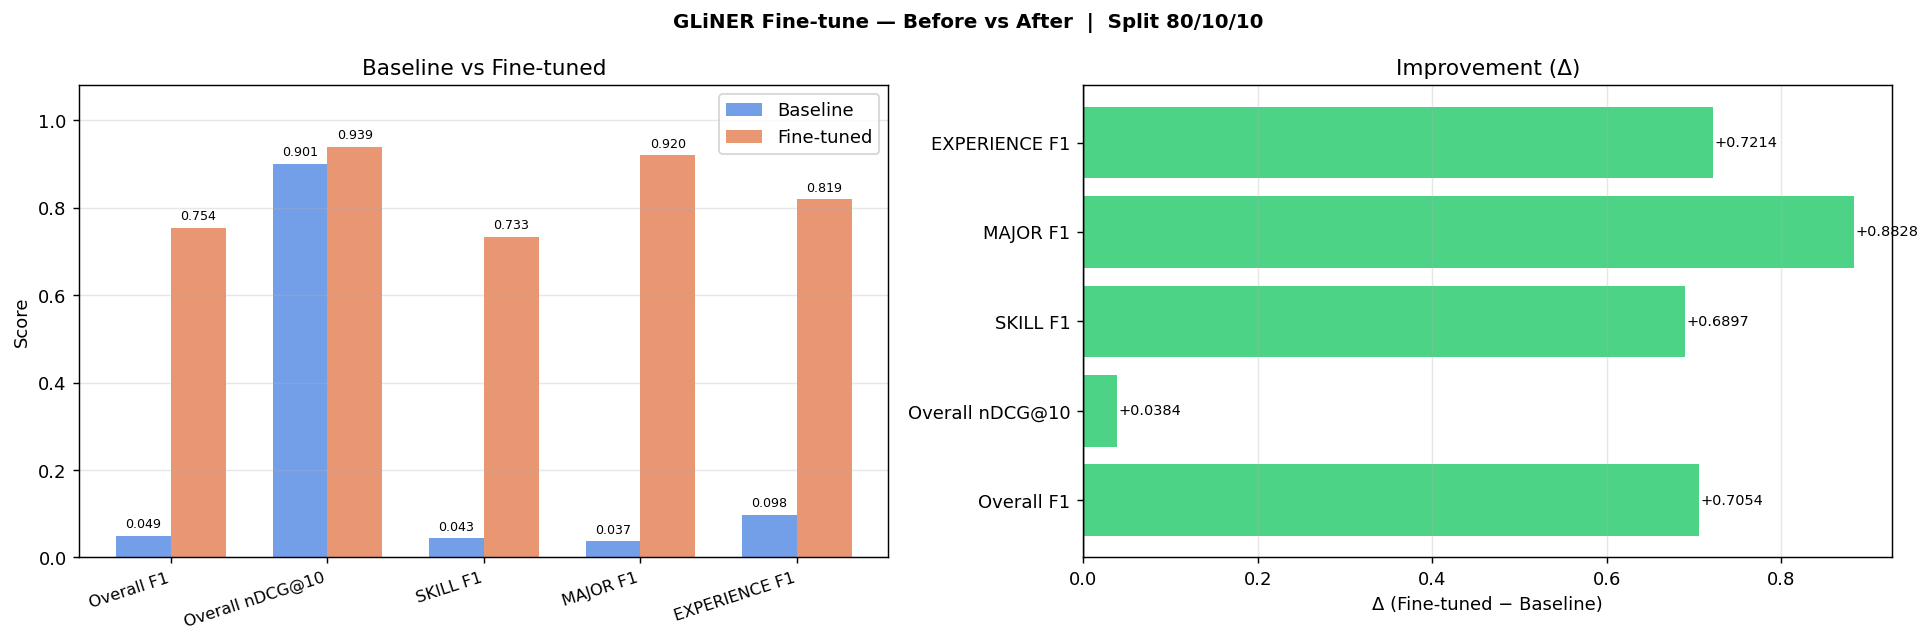

📊 Chart saved → /kaggle/working/comparison_chart.png


In [9]:
# ── 8. So sánh NDCG & F1 trước / sau fine-tune ───────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["figure.dpi"] = 130


def fmt_delta(after, before):
    d = after - before
    return f"{'+' if d >= 0 else ''}{d:.4f}"


print(f"\n{'='*65}")
print(f"  COMPARISON: BASELINE vs FINE-TUNED")
print(f"{'='*65}")
print(f"  {'Metric':<22} {'Baseline':>10} {'Fine-tuned':>12} {'Δ':>10}")
print(f"  {'─'*58}")

compare_rows = []

for metric_key, label in [("f1", "Overall F1"), (f"ndcg@{NDCG_K}", f"Overall nDCG@{NDCG_K}")]:
    b  = baseline_metrics["overall"][metric_key]
    ft = finetuned_metrics["overall"][metric_key]
    print(f"  {label:<22} {b:>10.4f} {ft:>12.4f} {fmt_delta(ft, b):>10}")
    compare_rows.append((label, b, ft))

print(f"  {'─'*58}")

for lbl in EVAL_LABELS:
    if lbl in baseline_metrics and lbl in finetuned_metrics:
        b  = baseline_metrics[lbl]["f1"]
        ft = finetuned_metrics[lbl]["f1"]
        print(f"  {lbl+' F1':<22} {b:>10.4f} {ft:>12.4f} {fmt_delta(ft, b):>10}")
        compare_rows.append((lbl + " F1", b, ft))

print(f"{'='*65}")

# ── Biểu đồ ──────────────────────────────────────────────────────────────────
labels_chart   = [r[0] for r in compare_rows]
baseline_vals  = [r[1] for r in compare_rows]
finetuned_vals = [r[2] for r in compare_rows]

x, w = range(len(labels_chart)), 0.35
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
bars_b = ax1.bar([i - w/2 for i in x], baseline_vals,  w, label="Baseline",   color="#5B8EE6", alpha=0.85)
bars_f = ax1.bar([i + w/2 for i in x], finetuned_vals, w, label="Fine-tuned", color="#E6855B", alpha=0.85)
ax1.set_xticks(list(x))
ax1.set_xticklabels(labels_chart, rotation=18, ha="right", fontsize=9)
ax1.set_ylim(0, 1.08)
ax1.set_ylabel("Score")
ax1.set_title("Baseline vs Fine-tuned")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)
for bar in list(bars_b) + list(bars_f):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)

# Delta chart
deltas = [ft - b for b, ft in zip(baseline_vals, finetuned_vals)]
colors = ["#2ECC71" if d >= 0 else "#E74C3C" for d in deltas]
bars_d = ax2.barh(labels_chart, deltas, color=colors, alpha=0.85)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_xlabel("Δ (Fine-tuned − Baseline)")
ax2.set_title("Improvement (Δ)")
ax2.grid(axis="x", alpha=0.3)
for bar, d in zip(bars_d, deltas):
    ax2.text(d + (0.002 if d >= 0 else -0.002),
             bar.get_y() + bar.get_height()/2,
             f"{'+' if d>=0 else ''}{d:.4f}",
             va="center", ha="left" if d >= 0 else "right", fontsize=8)

plt.suptitle(
    f"GLiNER Fine-tune — Before vs After  |  Split {TRAIN_RATIO*100:.0f}/{VAL_RATIO*100:.0f}/{TEST_RATIO*100:.0f}",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
chart_path = "/kaggle/working/comparison_chart.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"📊 Chart saved → {chart_path}")

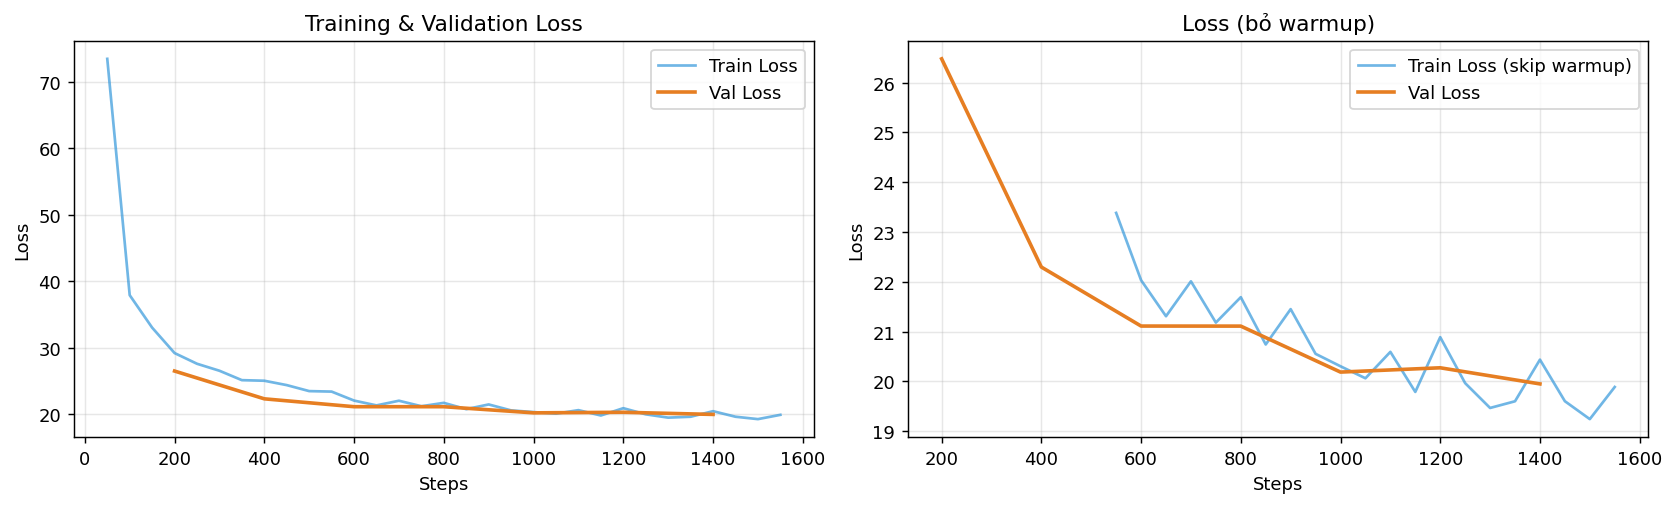

📊 Loss chart saved → /kaggle/working/training_loss.png


In [10]:
# ── 9. Training Loss Curve ────────────────────────────────────────────────────
log_history  = trainer.state.log_history
train_steps  = [x["step"] for x in log_history if "loss" in x]
train_losses = [x["loss"] for x in log_history if "loss" in x]
eval_steps   = [x["step"] for x in log_history if "eval_loss" in x]
eval_losses  = [x["eval_loss"] for x in log_history if "eval_loss" in x]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(train_steps, train_losses, label="Train Loss", color="#3498DB", alpha=0.7)
if eval_losses:
    ax1.plot(eval_steps, eval_losses, label="Val Loss", color="#E67E22", linewidth=2)
ax1.set(xlabel="Steps", ylabel="Loss", title="Training & Validation Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

if len(train_steps) > 20:
    skip = 10
    ax2.plot(train_steps[skip:], train_losses[skip:],
             label="Train Loss (skip warmup)", color="#3498DB", alpha=0.7)
    if eval_losses:
        ax2.plot(eval_steps, eval_losses, label="Val Loss", color="#E67E22", linewidth=2)
ax2.set(xlabel="Steps", ylabel="Loss", title="Loss (bỏ warmup)")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
loss_chart = "/kaggle/working/training_loss.png"
plt.savefig(loss_chart, dpi=150)
plt.show()
print(f"📊 Loss chart saved → {loss_chart}")

In [11]:
# ── 10. Lưu model & artifacts ─────────────────────────────────────────────────

# Zip model
zip_path = "/kaggle/working/gliner_finetuned"
shutil.make_archive(zip_path, "zip", OUTPUT_DIR)
print(f"📦 Model zipped → {zip_path}.zip")

# Lưu metrics JSON
metrics_out = {
    "split": {"train": TRAIN_RATIO, "val": VAL_RATIO, "test": TEST_RATIO},
    "baseline":  baseline_metrics,
    "finetuned": finetuned_metrics,
    "delta": {
        "overall_f1":             finetuned_metrics["overall"]["f1"] - baseline_metrics["overall"]["f1"],
        f"overall_ndcg@{NDCG_K}": finetuned_metrics["overall"][f"ndcg@{NDCG_K}"] - baseline_metrics["overall"][f"ndcg@{NDCG_K}"],
    }
}
with open("/kaggle/working/eval_results.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

print("\n✅ Artifacts đã lưu vào /kaggle/working/:")
for p in sorted(Path("/kaggle/working").iterdir()):
    size = p.stat().st_size / 1e6 if p.is_file() else 0
    print(f"   {p.name:<35} {size:>8.1f} MB" if p.is_file() else f"   {p.name}/")

📦 Model zipped → /kaggle/working/gliner_finetuned.zip

✅ Artifacts đã lưu vào /kaggle/working/:
   __notebook__.ipynb                       0.3 MB
   comparison_chart.png                     0.1 MB
   eval_results.json                        0.0 MB
   gliner_finetuned/
   gliner_finetuned.zip                  4406.9 MB
   training_loss.png                        0.1 MB
